
OPTIMIZED QUADROTOR SPARSE DYNAMICS DISCOVERY
WITH DATASET-SPECIFIC LAMBDA TUNING AND VISUALIZATION

OPTIMIZED - REAL FLIGHT DATA

RUNNING OPTIMIZED: Real Flight Data (Optimized)
Library shape: (956, 31)
Number of features: 31
Condition number: 1392195119538457344.00

   REAL DATA MODE: Using very small lambda (5e-05)
   Real data: using minimal threshold (1.066988)

--------------------------------------------------
RESULTS:
--------------------------------------------------
                        Dataset        MSE       MAE        R2  Latency (ms)  \
0  Real Flight Data (Optimized)  12.155816  1.608476  0.825111      3.720283   

   Complexity  Sparsity %  
0          31   83.333333  
Lambdas used: ['0.000034', '0.000034', '0.000034', '0.000102', '0.000102', '0.000102']

ENHANCED PHYSICS CHECK - Real Flight Data

Regularization used: ['0.000034', '0.000034', '0.000034', '0.000102', '0.000102', '0.000102']

1. GRAVITY IDENTIFICATION:
   acc_x = -1.3878 * grav_y
     ✓ Good magnitud

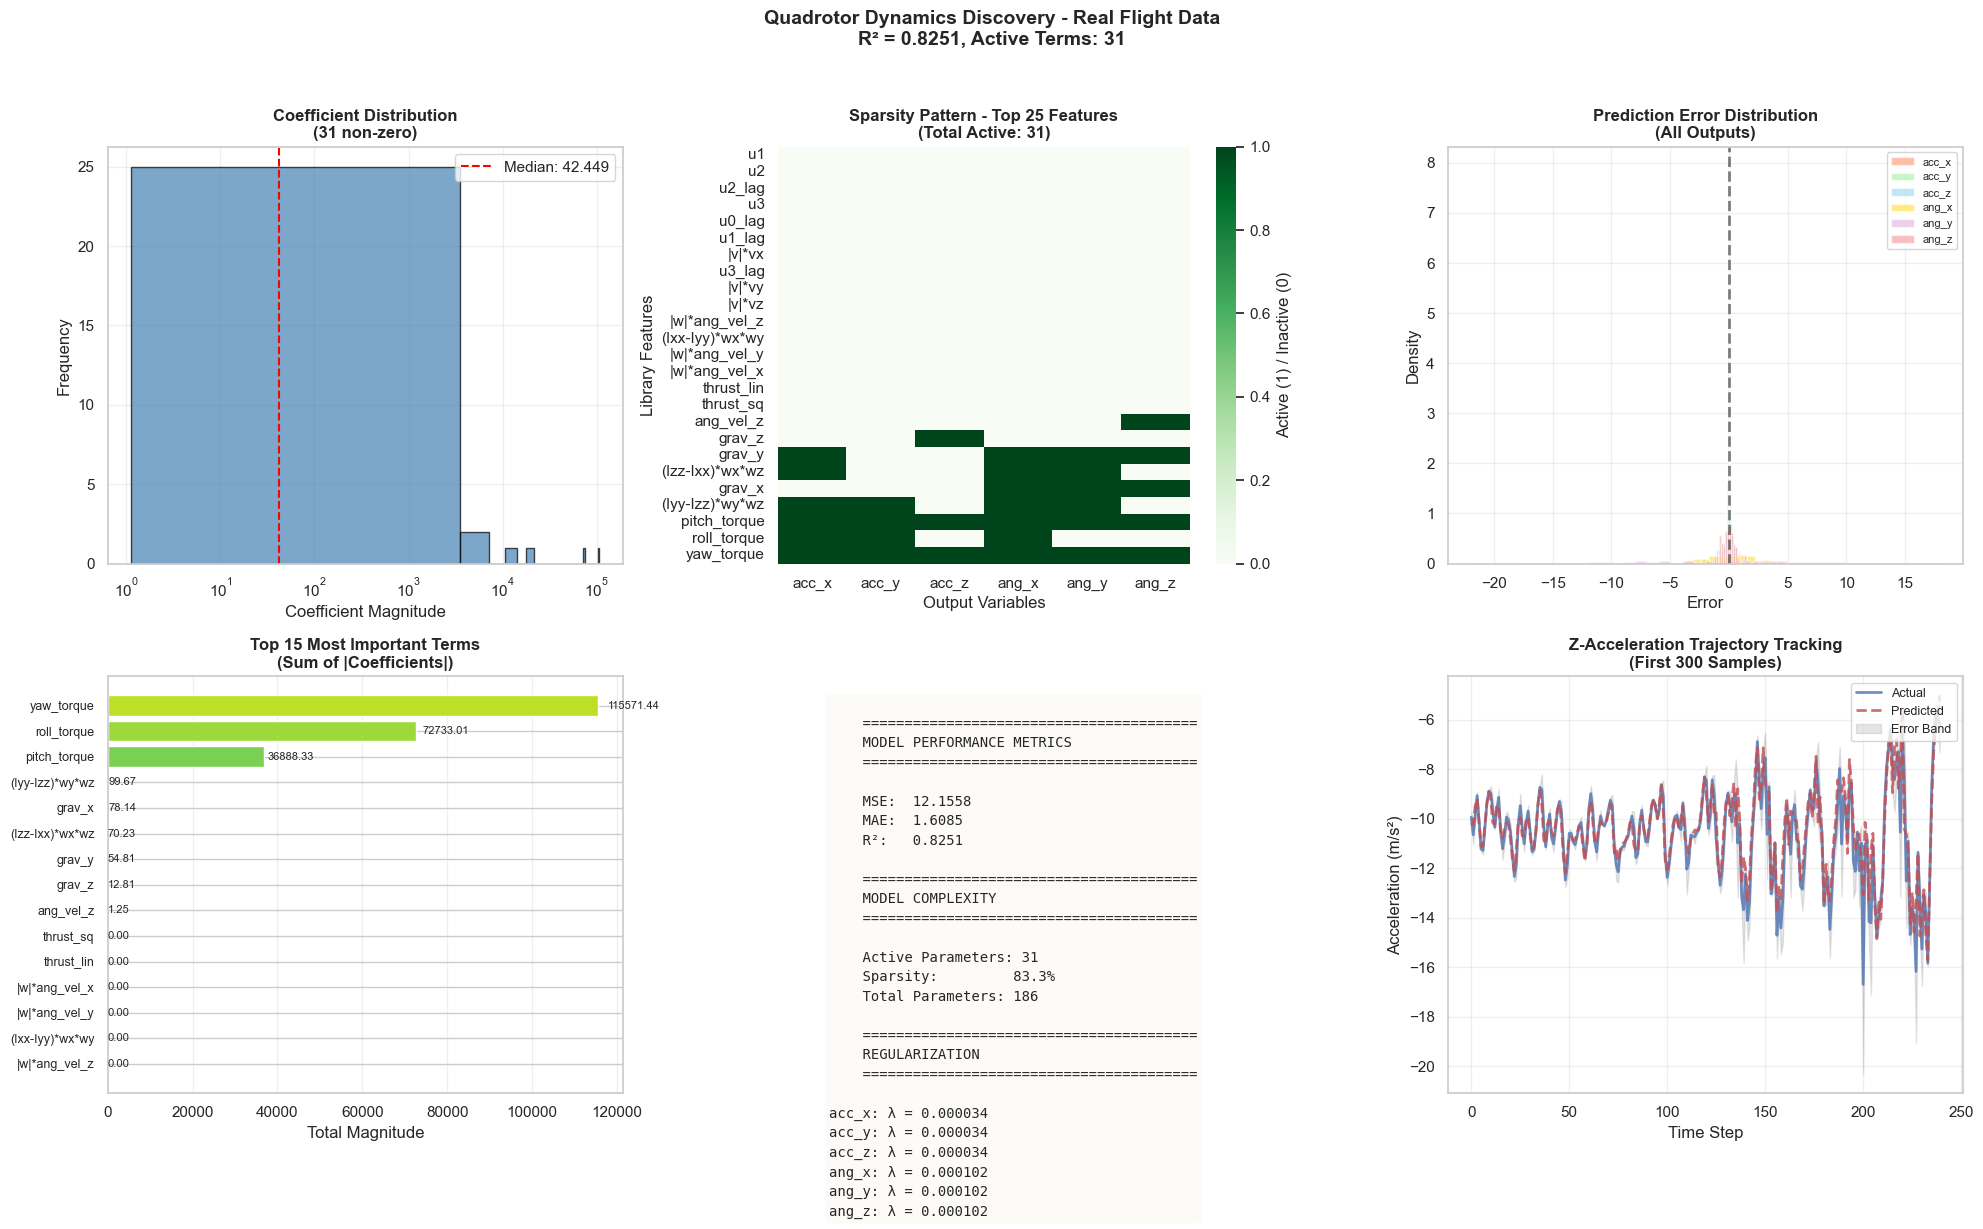

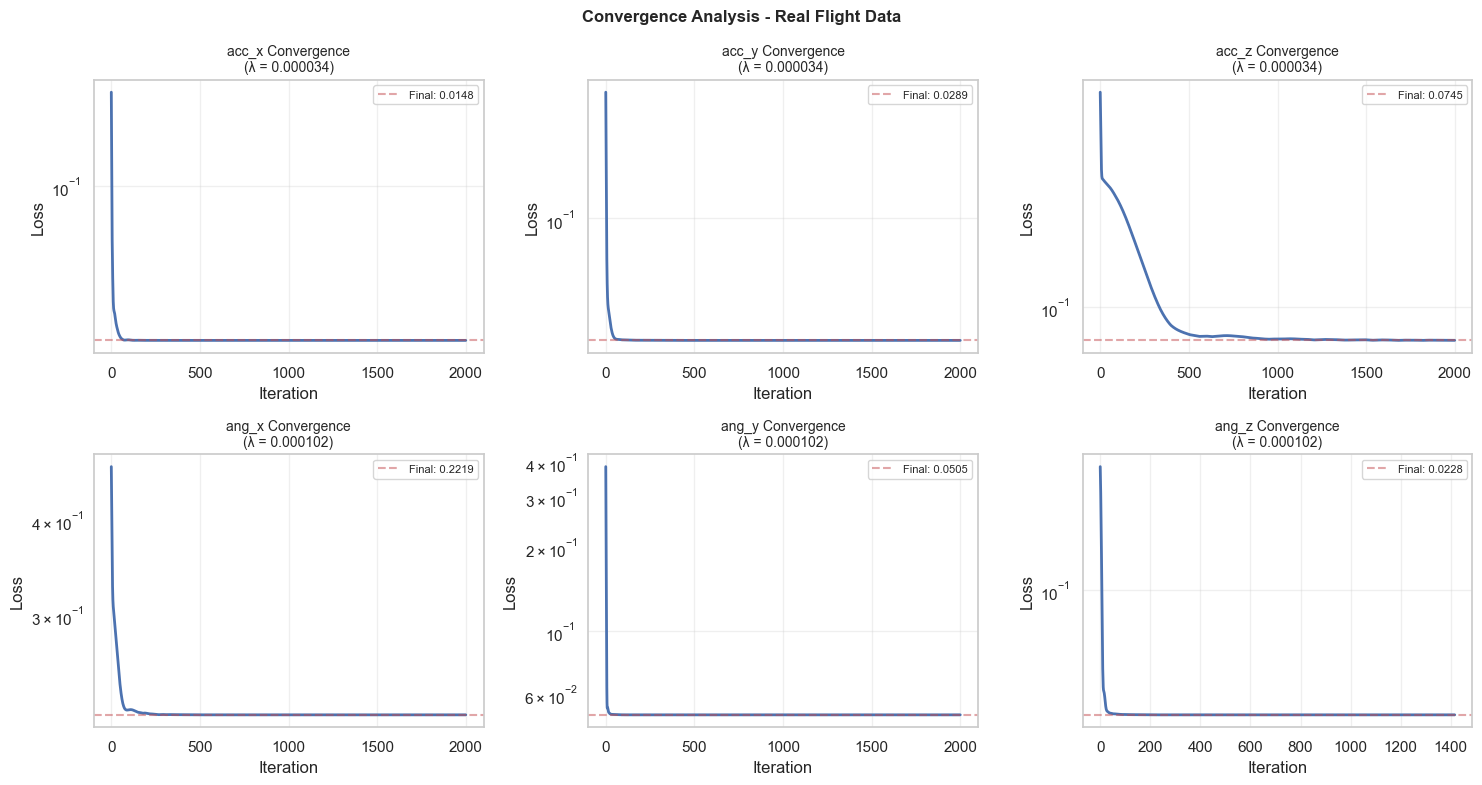

C:\Users\Priyan\AppData\Local\Temp\ipykernel_1644\528834279.py:491: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


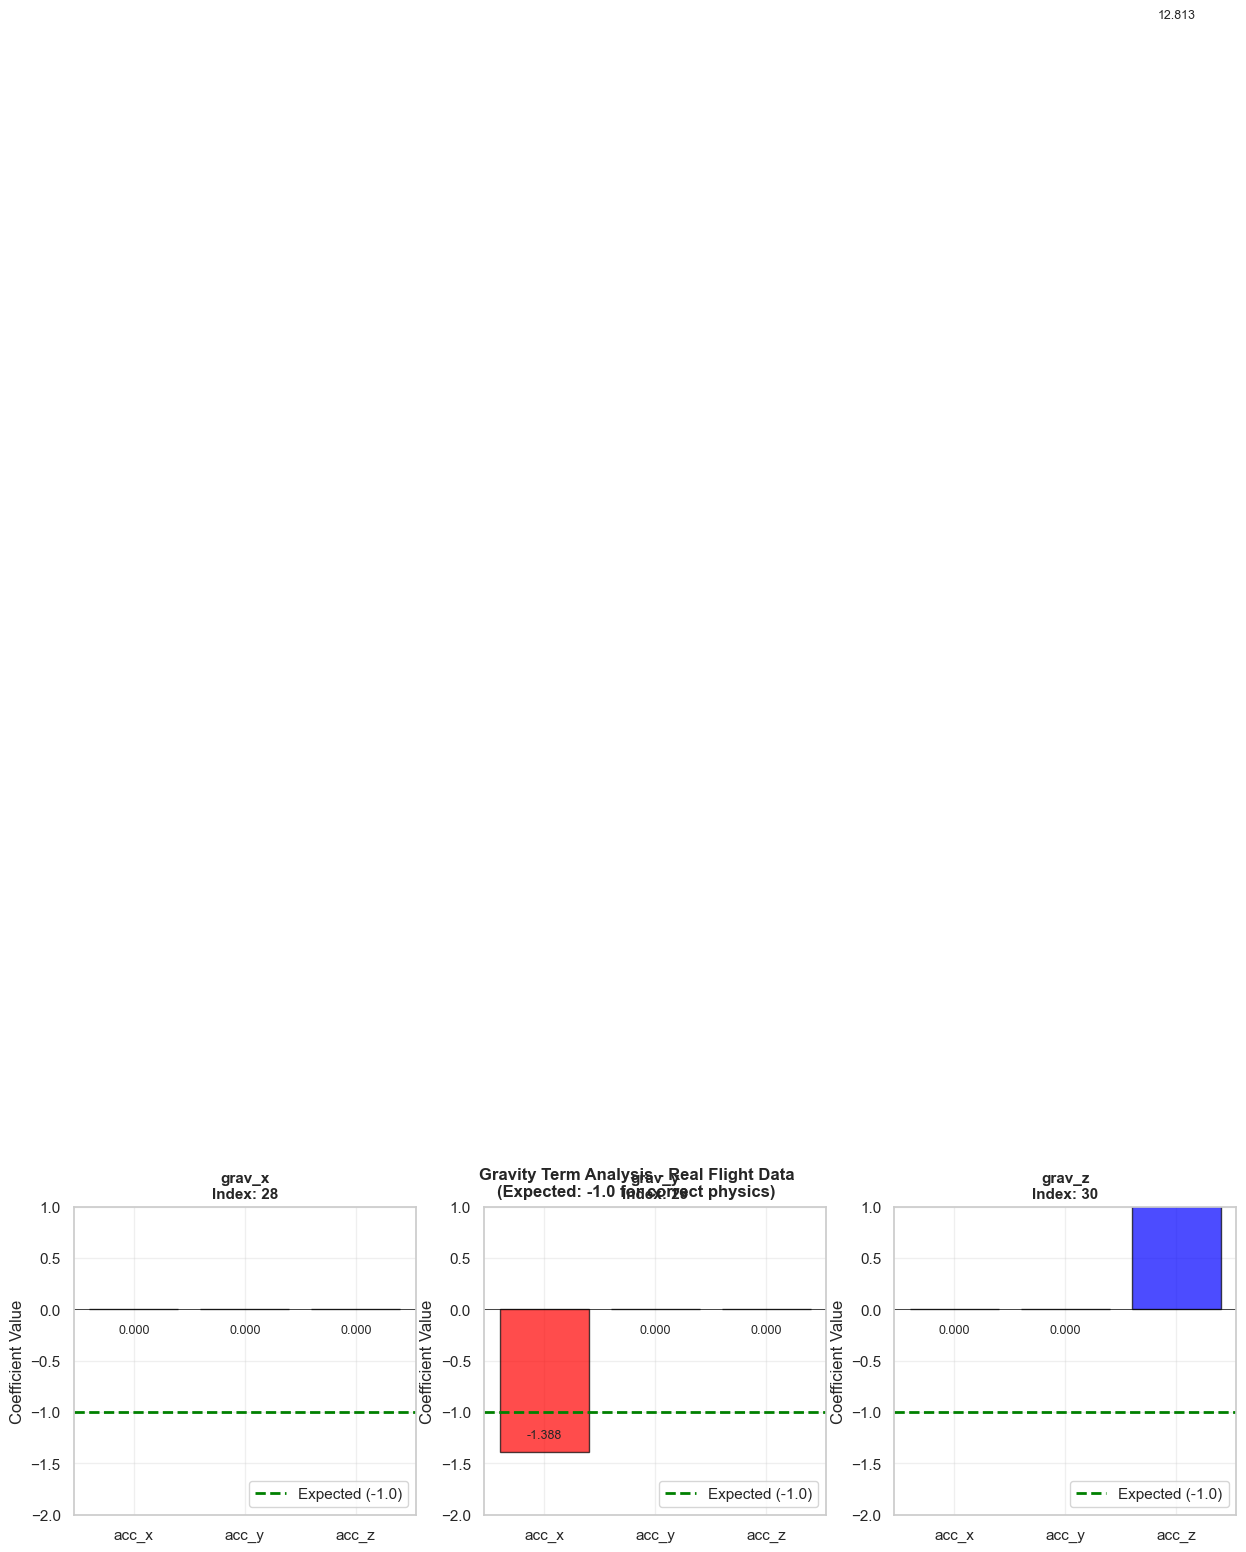

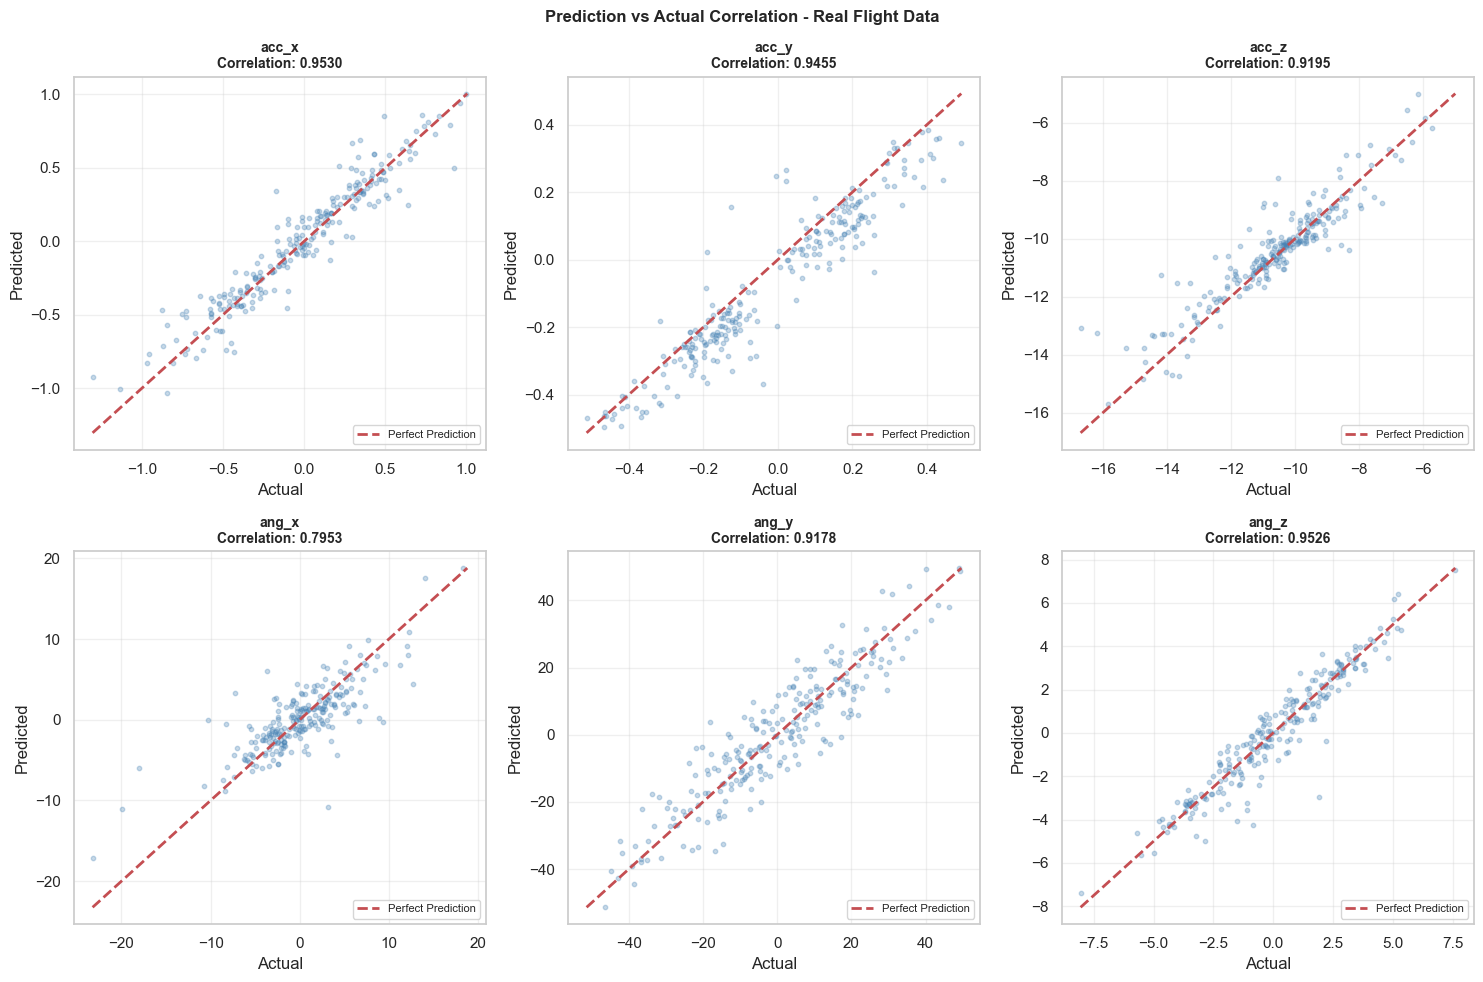

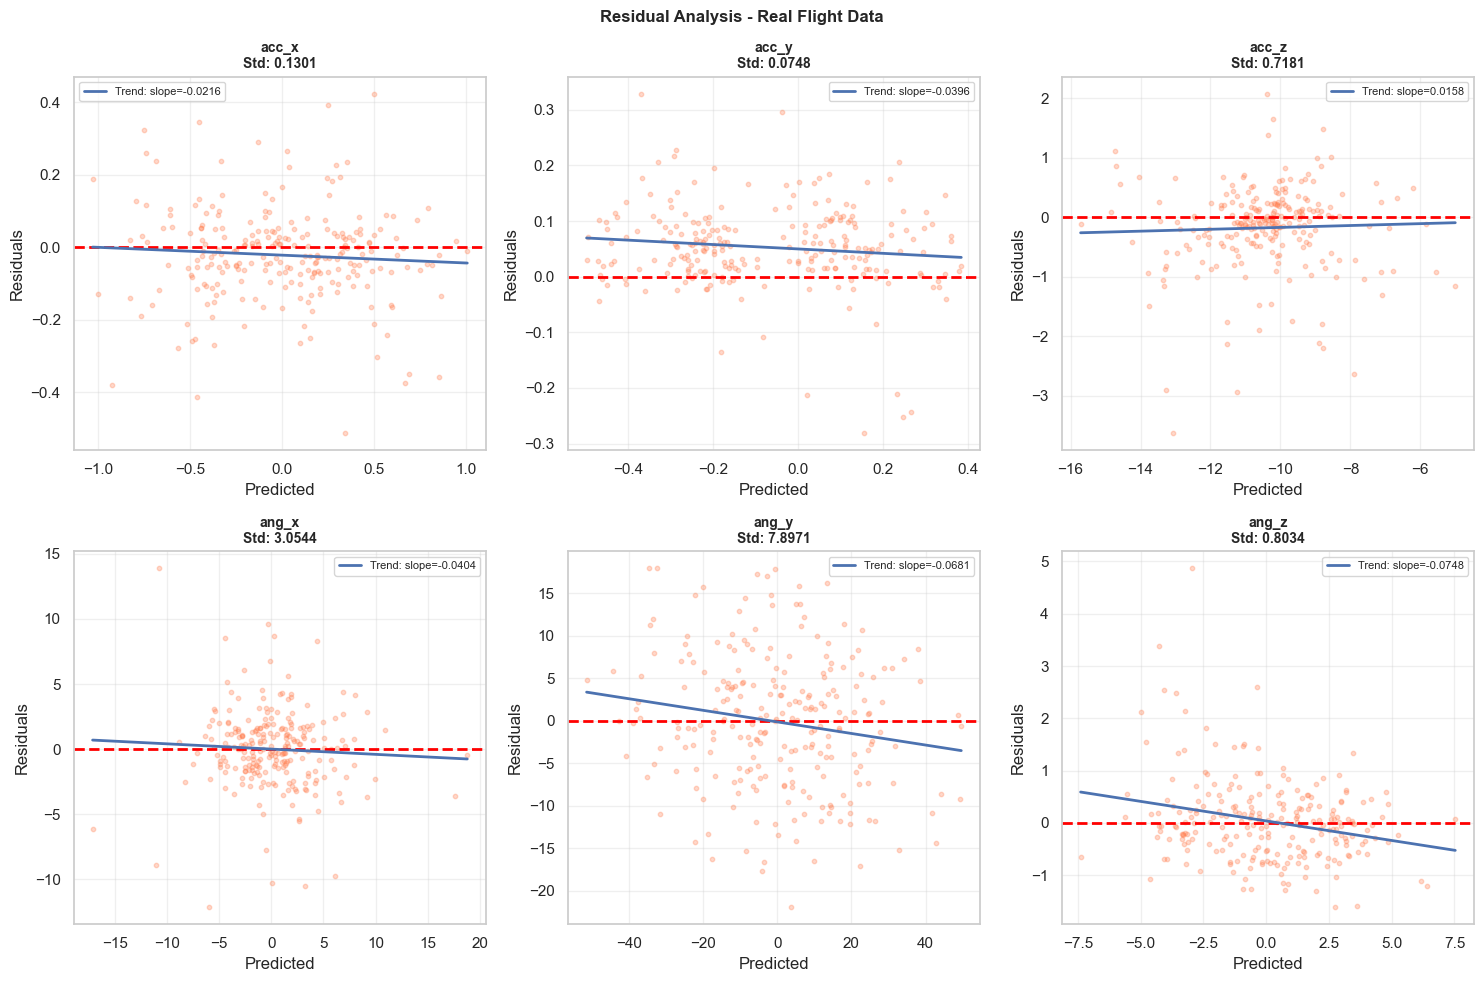


OPTIMIZED - SYNTHETIC DATA

RUNNING OPTIMIZED: Synthetic Dense Data (Optimized)
Library shape: (957, 31)
Number of features: 31
Condition number: 75075620740069916672.00

   SYNTHETIC DATA MODE: Using moderate lambda (0.0005)

--------------------------------------------------
RESULTS:
--------------------------------------------------
                            Dataset       MSE       MAE       R2  \
0  Synthetic Dense Data (Optimized)  0.353173  0.407928  0.92489   

   Latency (ms)  Complexity  Sparsity %  
0      3.039736          22   88.172043  
Lambdas used: ['0.000349', '0.000349', '0.000349', '0.001048', '0.001048', '0.001048']

ENHANCED PHYSICS CHECK - Synthetic Data

Regularization used: ['0.000349', '0.000349', '0.000349', '0.001048', '0.001048', '0.001048']

1. GRAVITY IDENTIFICATION:
   acc_x = -9.5687 * grav_x
   acc_z = 0.5758 * grav_x
   acc_y = -9.7380 * grav_y
   acc_z = 1.1428 * grav_y
   acc_x = -0.2565 * grav_z
   acc_y = -0.3158 * grav_z
   acc_z = -9.4252 * gr

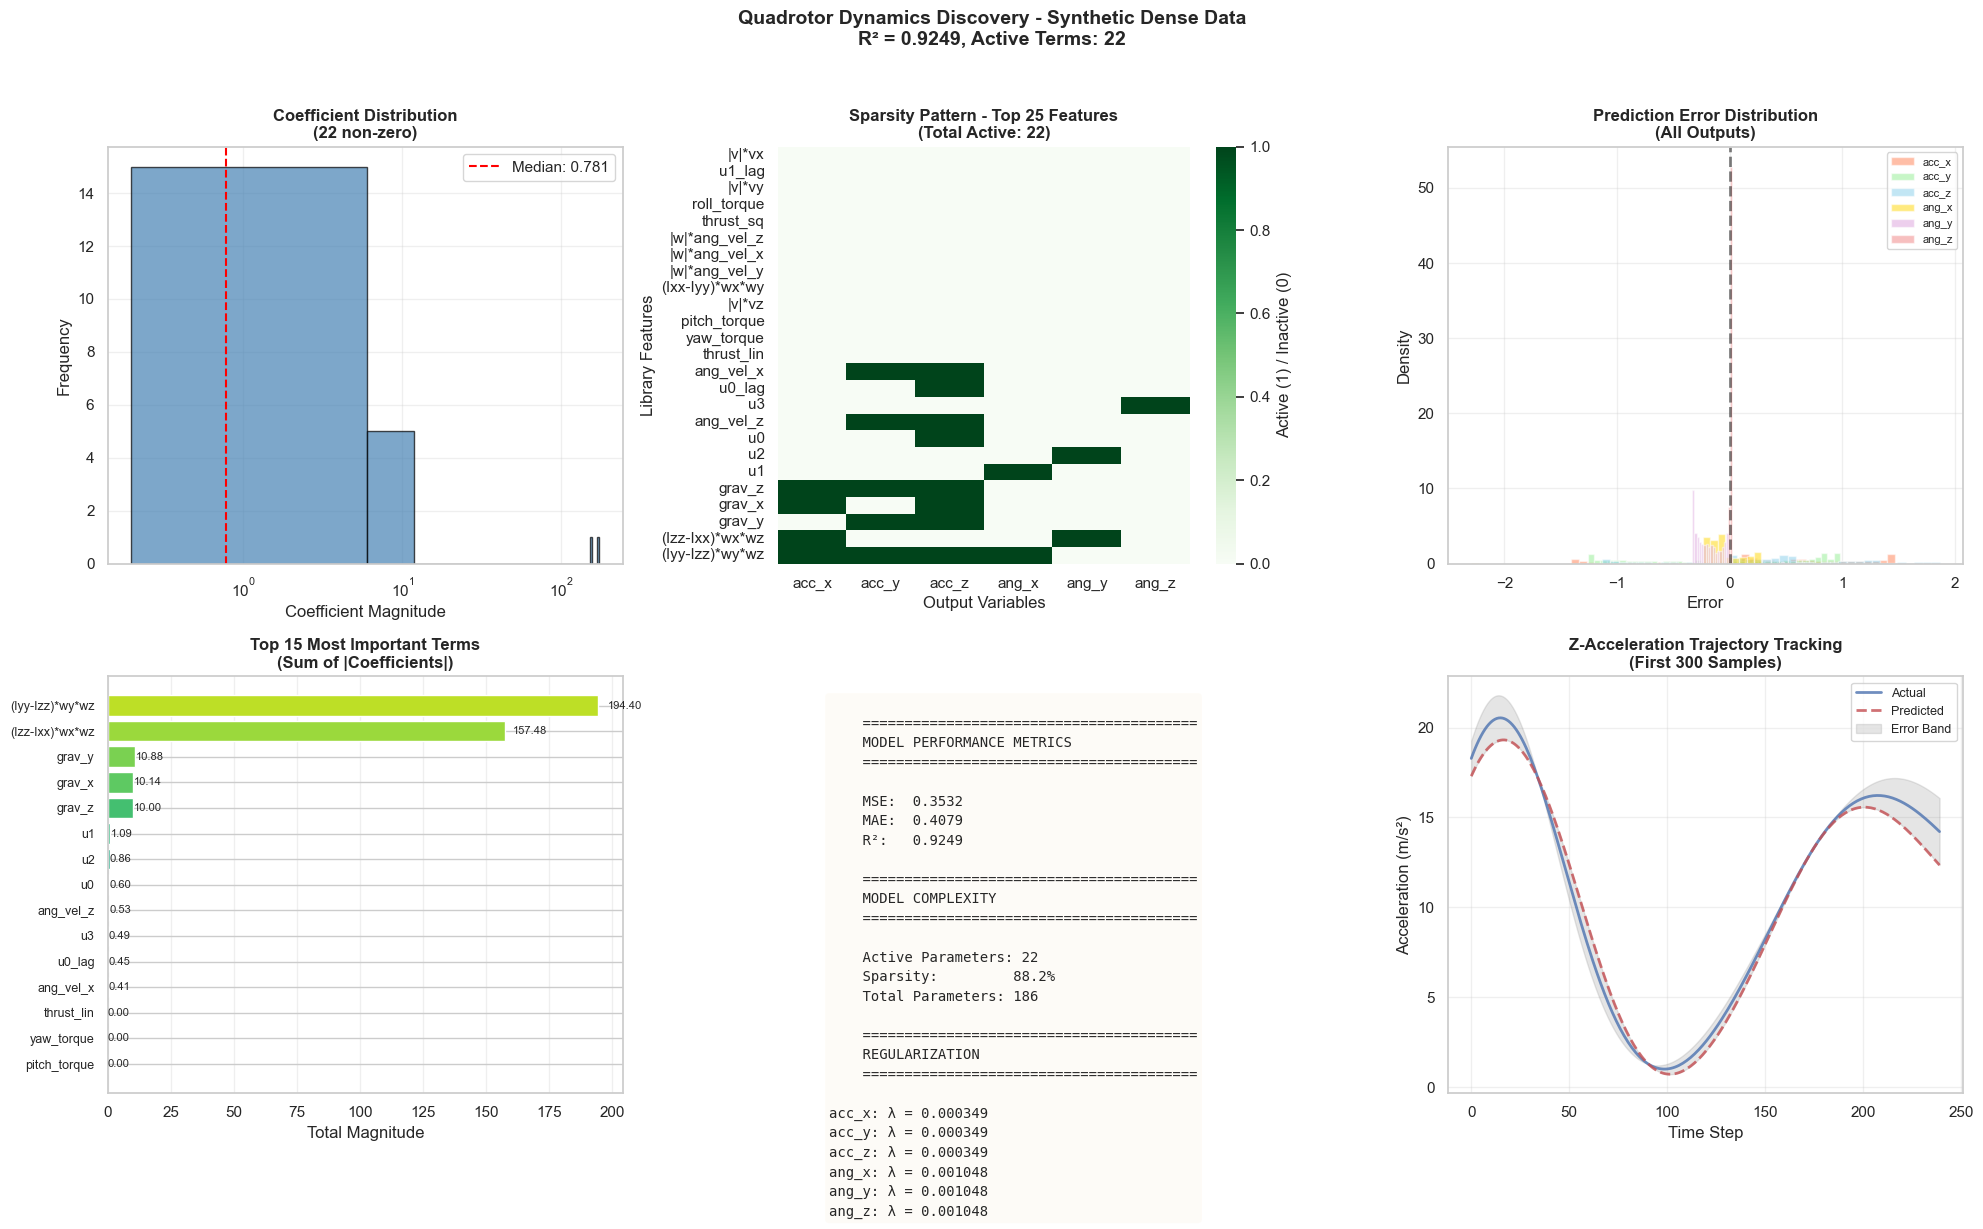

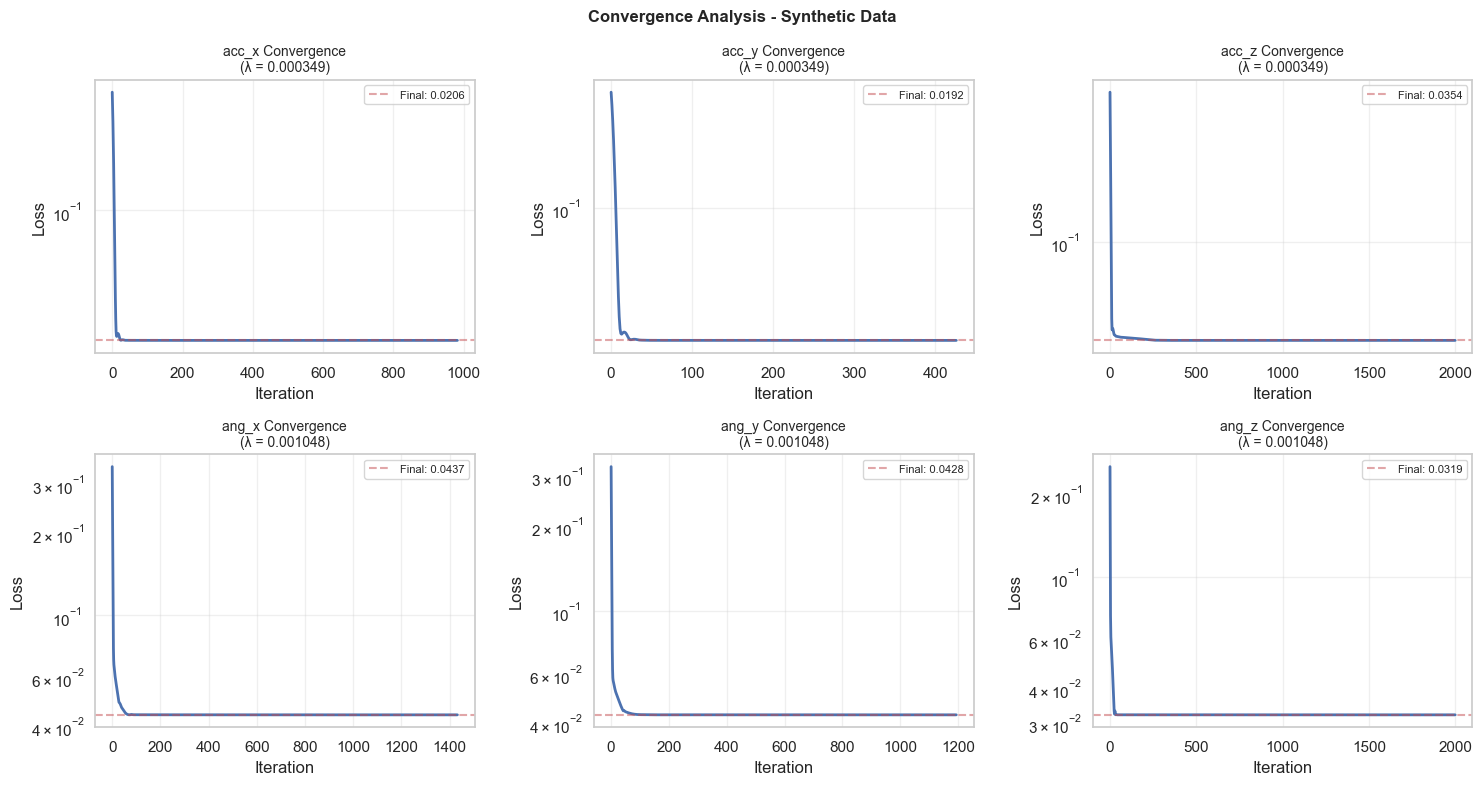

C:\Users\Priyan\AppData\Local\Temp\ipykernel_1644\528834279.py:491: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


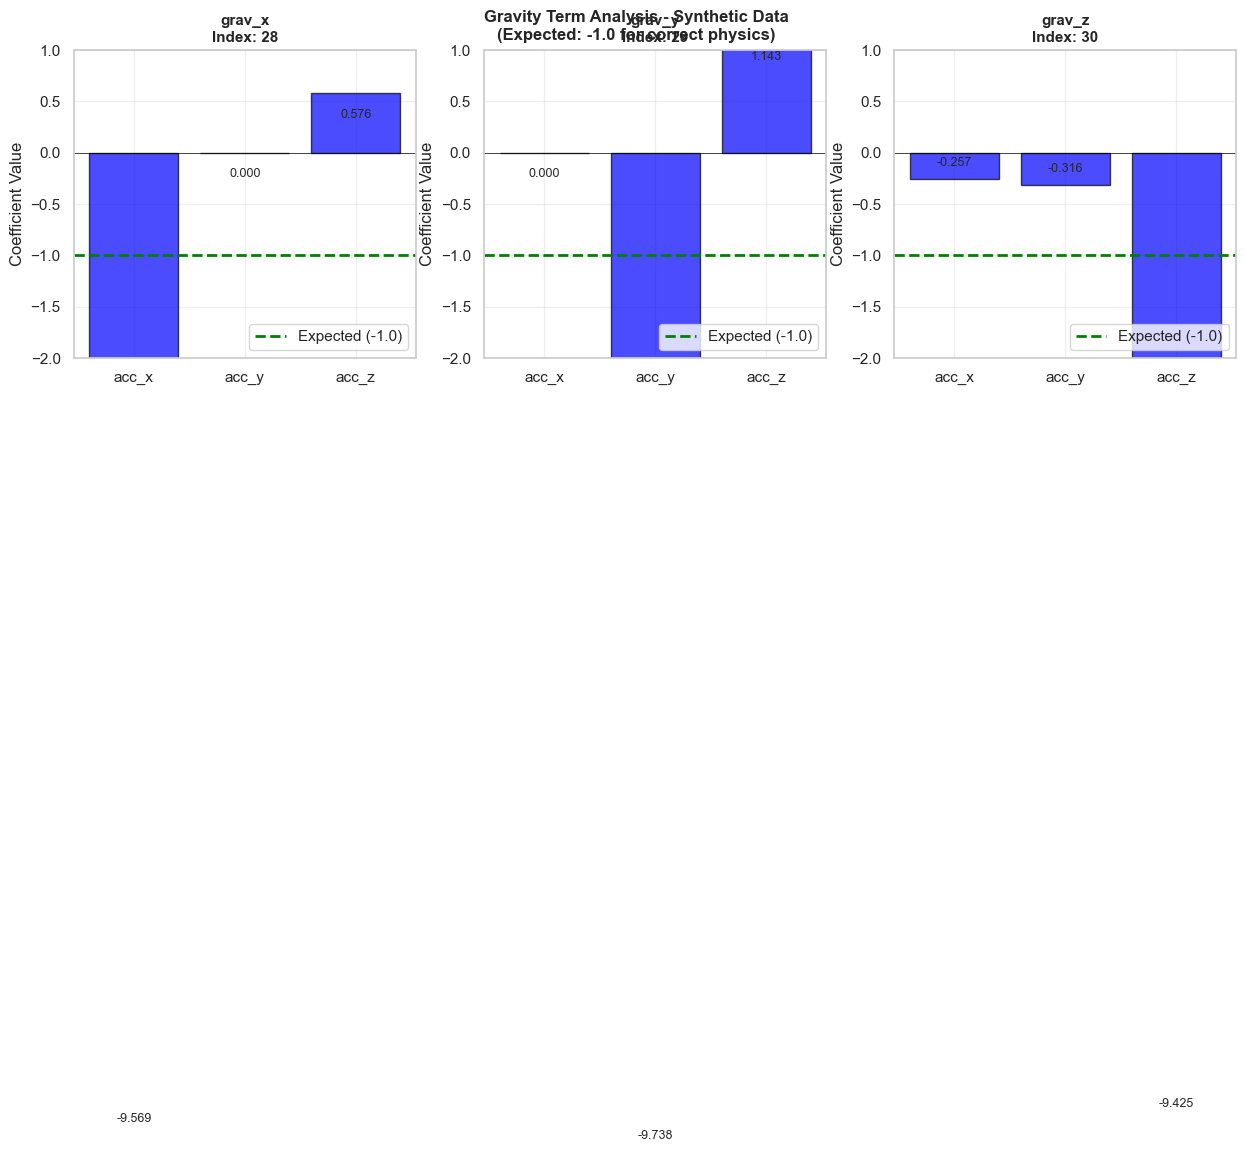

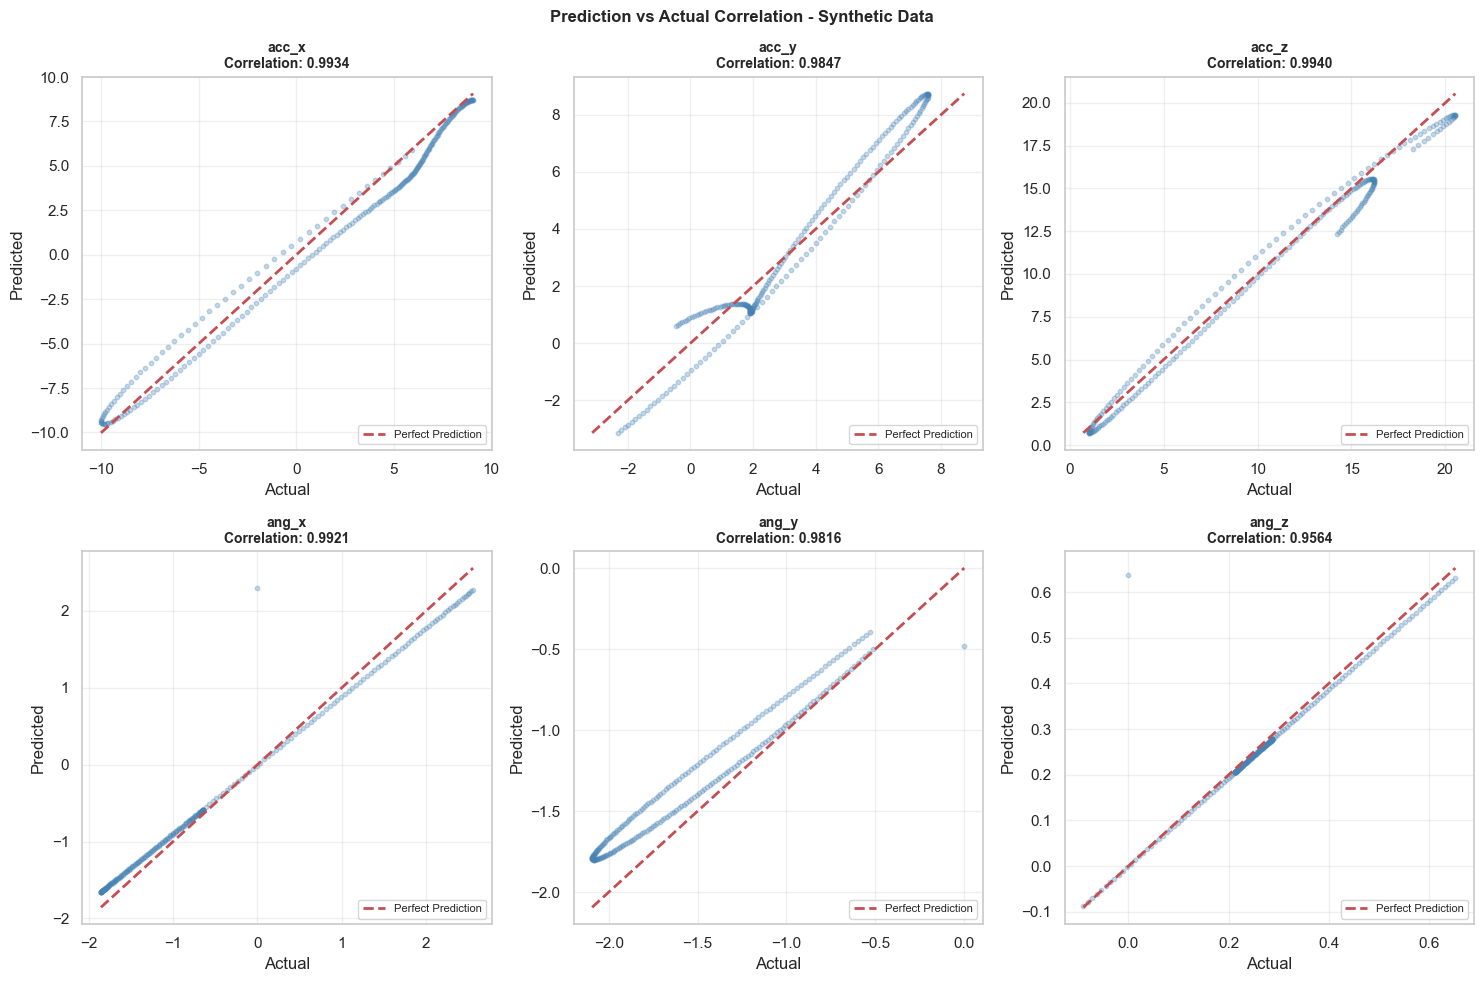

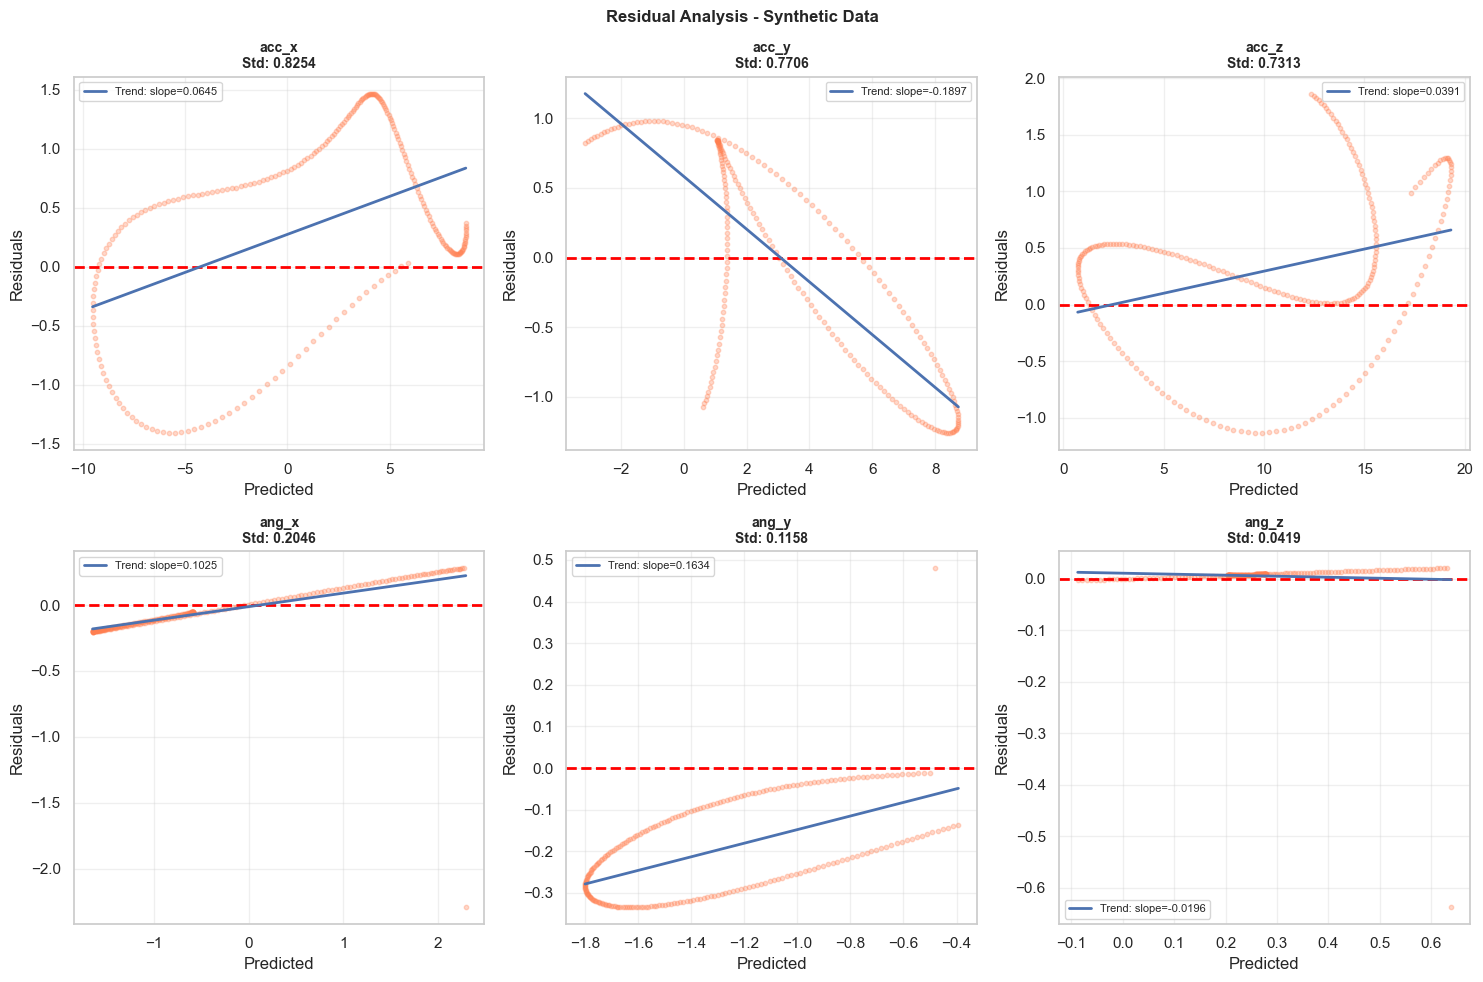


FINAL OPTIMIZED COMPARISON
                         Dataset       MSE      MAE       R2  Latency (ms)  Complexity  Sparsity %
    Real Flight Data (Optimized) 12.155816 1.608476 0.825111      3.720283          31   83.333333
Synthetic Dense Data (Optimized)  0.353173 0.407928 0.924890      3.039736          22   88.172043

----------------------------------------
IMPROVEMENT SUMMARY:
Real Data - Active parameters: 31
Real Data - R²: 0.825
Real Data - Physics Score: 40/100
Synthetic Data - Active parameters: 22
Synthetic Data - R²: 0.925
Synthetic Data - Physics Score: 90/100

GENERATING COMPARISON VISUALIZATION


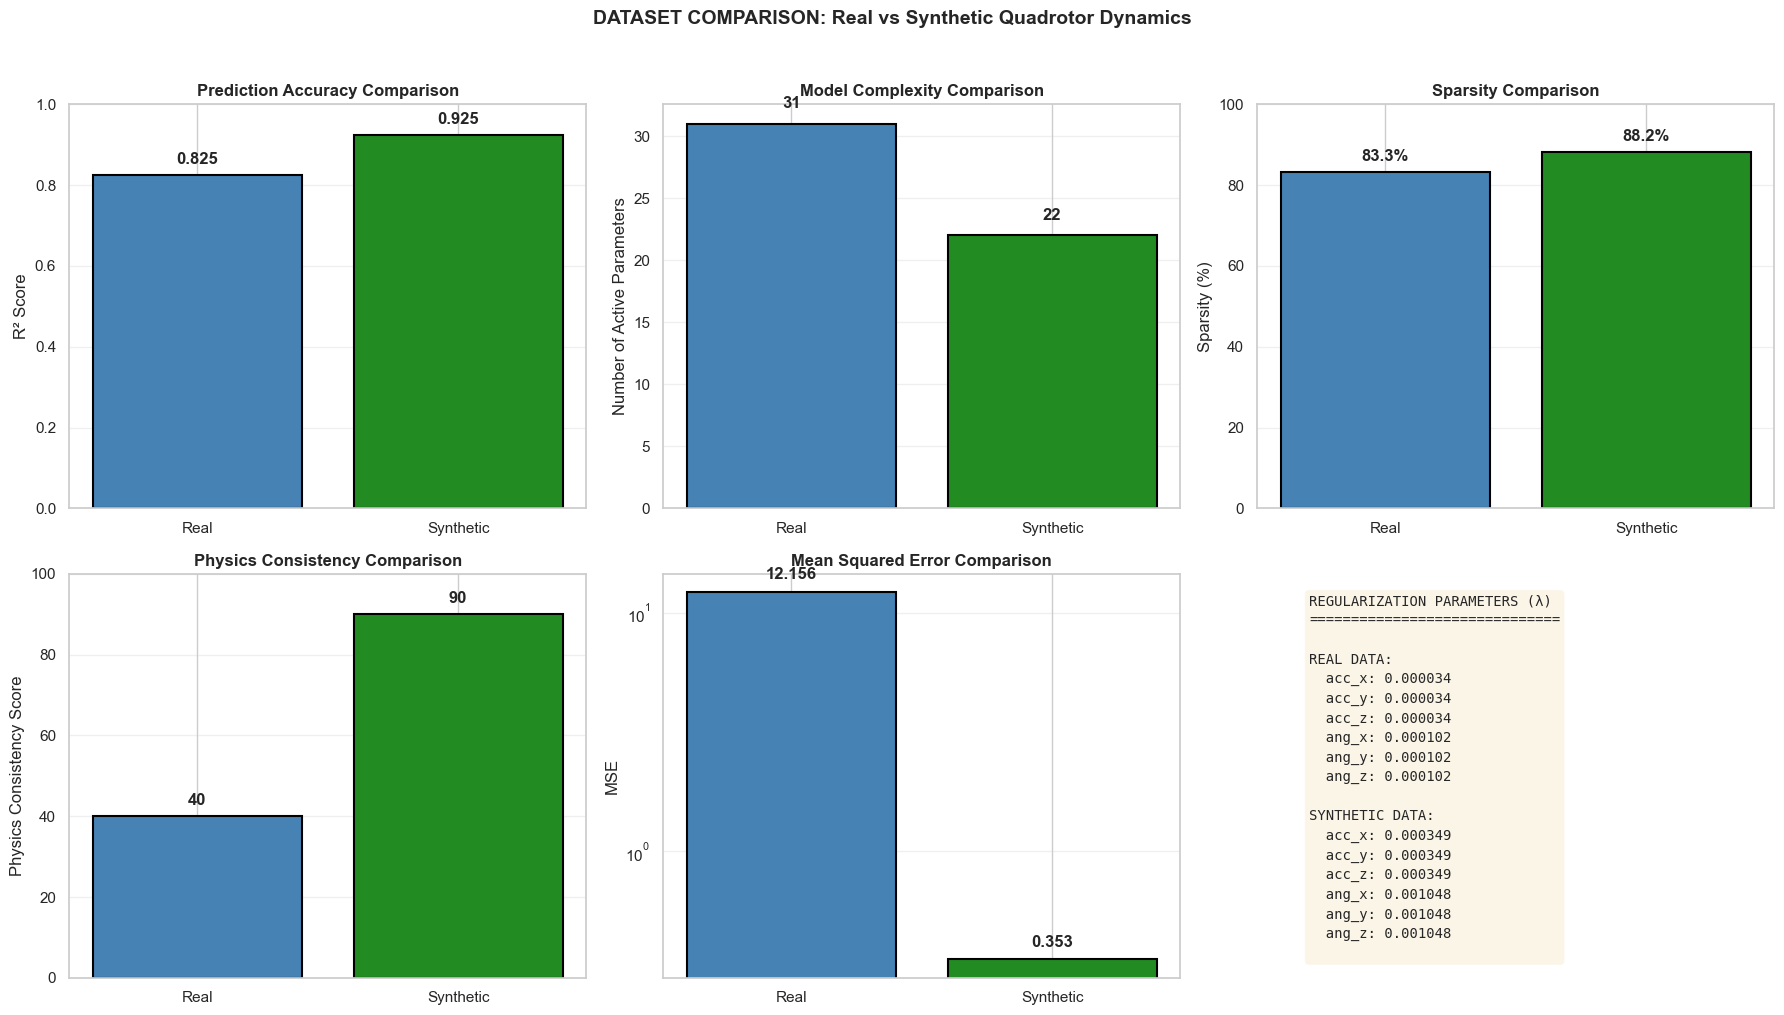


ANALYSIS COMPLETE - All figures saved to 'figures/' directory


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer

def gravity_body_frame(q):
    g = 9.81
    q0, q1, q2, q3 = q[:, 0], q[:, 1], q[:, 2], q[:, 3]
    
    norm = np.sqrt(q0**2 + q1**2 + q2**2 + q3**2)
    q0 = q0 / norm
    q1 = q1 / norm
    q2 = q2 / norm
    q3 = q3 / norm
    
    gx = 2 * (q1 * q3 - q0 * q2) * g
    gy = 2 * (q0 * q1 + q2 * q3) * g
    gz = (q0**2 - q1**2 - q2**2 + q3**2) * g
    
    return gx.reshape(-1, 1), gy.reshape(-1, 1), gz.reshape(-1, 1)

def proper_nondimensionalization(X, y, feature_names):
    X_nondim = X.copy()
    y_nondim = y.copy()
    scales_X = {}
    scales_y = {}
    
    for j in range(X.shape[1]):
        scale = np.std(X[:, j])
        if scale < 1e-6:
            scale = 1.0
        scales_X[feature_names[j]] = scale
        X_nondim[:, j] = X[:, j] / scale
    
    output_names = ['acc_x', 'acc_y', 'acc_z', 'ang_x', 'ang_y', 'ang_z']
    for j in range(y.shape[1]):
        scale = np.std(y[:, j])
        if scale < 1e-6:
            scale = 1.0
        scales_y[output_names[j]] = scale
        y_nondim[:, j] = y[:, j] / scale
    
    return X_nondim, y_nondim, scales_X, scales_y


# =========================================================
# DATA PREPARATION
# =========================================================
def prepare_data(df):
    df = df.drop(columns=['sno', 'timestamp', 'old_index', 'landed'], errors='ignore')
    
    motor_cols = ['u0', 'u1', 'u2', 'u3']
    df[['u0_lag', 'u1_lag', 'u2_lag', 'u3_lag']] = df[motor_cols].shift(1).bfill()
    df = df.interpolate(method='linear', limit_direction='both')
    
    feature_cols = [
        'vx', 'vy', 'vz',
        'q0', 'q1', 'q2', 'q3',
        'ang_vel_x', 'ang_vel_y', 'ang_vel_z',
        'u0', 'u1', 'u2', 'u3',
        'u0_lag', 'u1_lag', 'u2_lag', 'u3_lag'
    ]
    
    target_cols = [
        'acc_b_x', 'acc_b_y', 'acc_b_z',
        'ang_acc_b_x', 'ang_acc_b_y', 'ang_acc_b_z'
    ]
    
    X = df[feature_cols].values
    y = df[target_cols].values
    
    q_indices = [3, 4, 5, 6]
    for i in range(len(X)):
        q_norm = np.sqrt(np.sum(X[i, q_indices]**2))
        if q_norm > 0:
            X[i, q_indices] = X[i, q_indices] / q_norm
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)
    
    return X_train, X_test, y_train, y_test, feature_cols


# =========================================================
# NORMALIZE LIBRARY
# =========================================================
def normalize_library(Phi):
    norms = np.linalg.norm(Phi, axis=0)
    norms[norms < 1e-8] = 1
    Phi_norm = Phi / norms
    return Phi_norm, norms


# =========================================================
# PHYSICS-BASED LIBRARY
# =========================================================
def build_physics_library(X, names):
    n = X.shape[0]
    lib = []
    lib_names = []
    
    # Linear terms
    linear_indices = [0, 1, 2, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
    linear_names = [names[i] for i in linear_indices]
    lib.append(X[:, linear_indices])
    lib_names += linear_names
    
    # Quadratic drag
    v_idx = [0, 1, 2]
    v = X[:, v_idx]
    v_mag = np.linalg.norm(v, axis=1).reshape(-1, 1)
    for i in range(3):
        lib.append(v_mag * v[:, i].reshape(-1, 1))
        lib_names.append(f'|v|*{names[v_idx[i]]}')
    
    # Gyroscopic terms
    w_idx = [7, 8, 9]
    w = X[:, w_idx]
    Ixx, Iyy, Izz = 0.01, 0.01, 0.02
    
    gyro_x = ((Iyy - Izz) * w[:, 1] * w[:, 2]).reshape(-1, 1)
    lib.append(gyro_x)
    lib_names.append('(Iyy-Izz)*wy*wz')
    
    gyro_y = ((Izz - Ixx) * w[:, 0] * w[:, 2]).reshape(-1, 1)
    lib.append(gyro_y)
    lib_names.append('(Izz-Ixx)*wx*wz')
    
    gyro_z = ((Ixx - Iyy) * w[:, 0] * w[:, 1]).reshape(-1, 1)
    lib.append(gyro_z)
    lib_names.append('(Ixx-Iyy)*wx*wy')
    
    # Angular damping
    w_mag = np.linalg.norm(w, axis=1).reshape(-1, 1)
    for i in range(3):
        lib.append(w_mag * w[:, i].reshape(-1, 1))
        lib_names.append(f'|w|*{names[w_idx[i]]}')
    
    # Control terms
    u_idx = [10, 11, 12, 13]
    u = X[:, u_idx]
    u_squared = u**2
    
    lib.append(np.sum(u_squared, axis=1).reshape(-1, 1))
    lib_names.append('thrust_sq')
    
    lib.append(np.sum(u, axis=1).reshape(-1, 1))
    lib_names.append('thrust_lin')
    
    l, k_t, k_d = 0.2, 1e-5, 1e-6
    
    roll_torque = (u_squared[:, 0] - u_squared[:, 1] - u_squared[:, 2] + u_squared[:, 3]) * l * k_t
    lib.append(roll_torque.reshape(-1, 1))
    lib_names.append('roll_torque')
    
    pitch_torque = (-u_squared[:, 0] - u_squared[:, 1] + u_squared[:, 2] + u_squared[:, 3]) * l * k_t
    lib.append(pitch_torque.reshape(-1, 1))
    lib_names.append('pitch_torque')
    
    yaw_torque = (u_squared[:, 0] - u_squared[:, 1] + u_squared[:, 2] - u_squared[:, 3]) * k_d
    lib.append(yaw_torque.reshape(-1, 1))
    lib_names.append('yaw_torque')
    
    # Gravity terms (normalized)
    q = X[:, 3:7]
    gx, gy, gz = gravity_body_frame(q)
    lib += [gx/9.81, gy/9.81, gz/9.81]
    lib_names += ['grav_x', 'grav_y', 'grav_z']
    
    return np.hstack(lib), lib_names


# =========================================================
# OPTIMIZED CS-STLSQ WITH DATASET-SPECIFIC LAMBDA
# =========================================================
class OptimizedCSSTLSQ:
    def __init__(self, max_iter=2000, tol=1e-6):
        self.max_iter = max_iter
        self.tol = tol
        self.Xi = None
        self.lambdas_used = []
        self.loss_history = []
    
    def soft(self, x, t):
        return np.sign(x) * np.maximum(np.abs(x) - t, 0)
    
    def fit(self, Phi, y, dataset_type='real'):
        if len(y.shape) == 1:
            y = y.reshape(-1, 1)
        
        n, m = Phi.shape
        targets = y.shape[1]
        
        # ===== CRITICAL: Different lambdas for different datasets =====
        if dataset_type == 'real':
            # Real data needs MUCH smaller lambda to allow more terms
            base_lambda = 0.00005  # 20x smaller than before
            print(f"\n   REAL DATA MODE: Using very small lambda ({base_lambda})")
        else:
            # Synthetic data works well with moderate lambda
            base_lambda = 0.0005
            print(f"\n   SYNTHETIC DATA MODE: Using moderate lambda ({base_lambda})")
        
        # Condition number adjustment
        cond = np.linalg.cond(Phi)
        cond_factor = 1 + 0.02 * np.log10(cond)  # Milder adjustment
        
        L = np.linalg.norm(Phi, 2)**2 / n
        lr = 1 / L
        
        self.Xi = np.zeros((m, targets))
        self.lambdas_used = []
        self.loss_history = [[] for _ in range(targets)]
        
        for k in range(targets):
            # Per-output tuning
            if k < 3:  # Translational outputs (acceleration)
                lambda_k = base_lambda * cond_factor * 0.5  # Even smaller for translation
            else:  # Rotational outputs (angular acceleration)
                lambda_k = base_lambda * cond_factor * 1.5  # Slightly larger for rotation
            
            self.lambdas_used.append(lambda_k)
            
            x = np.zeros(m)
            z = x.copy()
            t = 1
            
            for iteration in range(self.max_iter):
                grad = Phi.T @ (Phi @ z - y[:, k]) / n
                x_new = self.soft(z - lr * grad, lambda_k * lr)
                
                t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
                z = x_new + ((t - 1) / t_new) * (x_new - x)
                
                # Track loss
                loss = 0.5 * np.linalg.norm(Phi @ x_new - y[:, k])**2 / n + lambda_k * np.sum(np.abs(x_new))
                self.loss_history[k].append(loss)
                
                if np.linalg.norm(x_new - x) < self.tol:
                    break
                
                x = x_new
                t = t_new
            
            self.Xi[:, k] = x
        
        return self
    
    def predict(self, Phi):
        return Phi @ self.Xi


# =========================================================
# ENHANCED VISUALIZATION FUNCTIONS
# =========================================================

def plot_comprehensive_analysis(stats, Xi, lib_names, y_test, preds, lambdas, dataset_name):
    """
    Create comprehensive 2x3 visualization panel for each dataset
    """
    sns.set_theme(style="whitegrid")
    fig = plt.figure(figsize=(20, 12))
    
    outputs = ['acc_x', 'acc_y', 'acc_z', 'ang_x', 'ang_y', 'ang_z']
    
    # ===== 1. Coefficient Magnitude Distribution =====
    ax1 = plt.subplot(2, 3, 1)
    coefs = np.abs(Xi).flatten()
    coefs = coefs[coefs > 1e-6]
    
    ax1.hist(coefs, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.set_title(f'Coefficient Distribution\n({len(coefs)} non-zero)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Coefficient Magnitude')
    ax1.set_ylabel('Frequency')
    ax1.set_xscale('log')
    ax1.axvline(x=np.median(coefs) if len(coefs) > 0 else 0, 
                color='red', linestyle='--', label=f'Median: {np.median(coefs):.3f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # ===== 2. Sparsity Pattern Heatmap =====
    ax2 = plt.subplot(2, 3, 2)
    mask = np.abs(Xi) > 1e-6
    n_features = min(25, mask.shape[0])
    
    # Get top features by importance
    importance = np.sum(np.abs(Xi), axis=1)
    top_feat_idx = np.argsort(importance)[-n_features:]
    
    sns.heatmap(mask[top_feat_idx, :].astype(float), 
                cmap="Greens",
                cbar_kws={'label': 'Active (1) / Inactive (0)'},
                yticklabels=[lib_names[i] for i in top_feat_idx],
                xticklabels=outputs,
                ax=ax2)
    ax2.set_title(f'Sparsity Pattern - Top {n_features} Features\n(Total Active: {np.sum(mask)})', 
                  fontsize=12, fontweight='bold')
    ax2.set_xlabel('Output Variables')
    ax2.set_ylabel('Library Features')
    
    # ===== 3. Prediction Error Distribution =====
    ax3 = plt.subplot(2, 3, 3)
    errors = {}
    colors = ['coral', 'lightgreen', 'skyblue', 'gold', 'plum', 'lightcoral']
    
    for i, out in enumerate(outputs):
        error = y_test[:, i] - preds[:, i]
        errors[out] = error
        ax3.hist(error, bins=40, alpha=0.5, label=out, color=colors[i], density=True)
    
    ax3.set_title('Prediction Error Distribution\n(All Outputs)', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Error')
    ax3.set_ylabel('Density')
    ax3.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.5)
    ax3.legend(loc='upper right', fontsize=8)
    ax3.grid(True, alpha=0.3)
    
    # ===== 4. Top 15 Most Important Terms =====
    ax4 = plt.subplot(2, 3, 4)
    importance = np.sum(np.abs(Xi), axis=1)
    n_top = min(15, len(importance))
    top_idx = np.argsort(importance)[-n_top:]
    top_vals = importance[top_idx]
    top_names = [lib_names[i] for i in top_idx]
    
    colors_imp = plt.cm.viridis(np.linspace(0.2, 0.9, n_top))
    bars = ax4.barh(range(n_top), top_vals, color=colors_imp)
    ax4.set_yticks(range(n_top))
    ax4.set_yticklabels(top_names, fontsize=9)
    ax4.set_title(f'Top {n_top} Most Important Terms\n(Sum of |Coefficients|)', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Total Magnitude')
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, top_vals)):
        ax4.text(val * 1.02, i, f'{val:.2f}', va='center', fontsize=8)
    
    ax4.grid(True, alpha=0.3, axis='x')
    
    # ===== 5. Performance Metrics and Lambdas =====
    ax5 = plt.subplot(2, 3, 5)
    ax5.axis('off')
    
    # Create metrics table
    metrics_text = f"""
    {'='*40}
    MODEL PERFORMANCE METRICS
    {'='*40}
    
    MSE:  {stats['MSE'].iloc[0]:.4f}
    MAE:  {stats['MAE'].iloc[0]:.4f}
    R²:   {stats['R2'].iloc[0]:.4f}
    
    {'='*40}
    MODEL COMPLEXITY
    {'='*40}
    
    Active Parameters: {stats['Complexity'].iloc[0]}
    Sparsity:         {stats['Sparsity %'].iloc[0]:.1f}%
    Total Parameters: {Xi.size}
    
    {'='*40}
    REGULARIZATION
    {'='*40}
    """
    
    for i, (out, lam) in enumerate(zip(outputs, lambdas)):
        metrics_text += f"\n{out}: λ = {lam:.6f}"
    
    ax5.text(0.1, 0.95, metrics_text, transform=ax5.transAxes,
             fontsize=10, verticalalignment='top',
             fontfamily='monospace', linespacing=1.5,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.1))
    
    # ===== 6. Trajectory Tracking (Z-acceleration) =====
    ax6 = plt.subplot(2, 3, 6)
    n_points = min(300, len(y_test))
    time_steps = np.arange(n_points)
    
    ax6.plot(time_steps, y_test[:n_points, 2], 'b-', label='Actual', linewidth=2, alpha=0.8)
    ax6.plot(time_steps, preds[:n_points, 2], 'r--', label='Predicted', linewidth=2, alpha=0.8)
    
    # Add confidence band
    error_band = np.abs(y_test[:n_points, 2] - preds[:n_points, 2])
    ax6.fill_between(time_steps, 
                     y_test[:n_points, 2] - error_band,
                     y_test[:n_points, 2] + error_band,
                     alpha=0.2, color='gray', label='Error Band')
    
    ax6.set_title('Z-Acceleration Trajectory Tracking\n(First 300 Samples)', fontsize=12, fontweight='bold')
    ax6.set_xlabel('Time Step')
    ax6.set_ylabel('Acceleration (m/s²)')
    ax6.legend(loc='upper right', fontsize=9)
    ax6.grid(True, alpha=0.3)
    
    plt.suptitle(f'Quadrotor Dynamics Discovery - {dataset_name}\nR² = {stats["R2"].iloc[0]:.4f}, Active Terms: {stats["Complexity"].iloc[0]}', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig


def plot_convergence_analysis(model, dataset_name):
    """
    Plot convergence history for each output
    """
    if not hasattr(model, 'loss_history') or not model.loss_history:
        return
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    outputs = ['acc_x', 'acc_y', 'acc_z', 'ang_x', 'ang_y', 'ang_z']
    
    for i, ax in enumerate(axes.flat):
        if i < len(model.loss_history) and len(model.loss_history[i]) > 0:
            loss = model.loss_history[i]
            ax.semilogy(loss, linewidth=2)
            ax.set_title(f'{outputs[i]} Convergence\n(λ = {model.lambdas_used[i]:.6f})', fontsize=10)
            ax.set_xlabel('Iteration')
            ax.set_ylabel('Loss')
            ax.grid(True, alpha=0.3)
            
            # Mark convergence
            if len(loss) > 1:
                final_loss = loss[-1]
                ax.axhline(y=final_loss, color='r', linestyle='--', alpha=0.5, label=f'Final: {final_loss:.4f}')
                ax.legend(fontsize=8)
    
    plt.suptitle(f'Convergence Analysis - {dataset_name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_gravity_analysis(Xi, lib_names, dataset_name):
    """
    Specialized plot for gravity term analysis
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    gravity_terms = ['grav_x', 'grav_y', 'grav_z']
    outputs = ['acc_x', 'acc_y', 'acc_z']
    
    for i, (grav, ax) in enumerate(zip(gravity_terms, axes)):
        if grav in lib_names:
            idx = lib_names.index(grav)
            coefs = Xi[idx, :3]  # Coefficients for acceleration outputs
            
            # Plot coefficients
            x_pos = np.arange(3)
            colors = ['red' if np.abs(c - (-1.0)) < 0.5 else 'blue' for c in coefs]
            bars = ax.bar(x_pos, coefs, color=colors, alpha=0.7, edgecolor='black')
            
            # Expected value line
            ax.axhline(y=-1.0, color='green', linestyle='--', linewidth=2, label='Expected (-1.0)')
            
            # Zero line
            ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
            
            ax.set_xticks(x_pos)
            ax.set_xticklabels(outputs)
            ax.set_title(f'{grav}\nIndex: {idx}', fontsize=11, fontweight='bold')
            ax.set_ylabel('Coefficient Value')
            ax.set_ylim([-2, 1])
            ax.legend(loc='lower right')
            ax.grid(True, alpha=0.3)
            
            # Add value labels
            for bar, val in zip(bars, coefs):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + (0.1 if height < 0 else -0.15),
                       f'{val:.3f}', ha='center', va='bottom' if height < 0 else 'top', fontsize=9)
    
    plt.suptitle(f'Gravity Term Analysis - {dataset_name}\n(Expected: -1.0 for correct physics)', 
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_correlation_heatmap(y_test, preds, dataset_name):
    """
    Plot correlation between predicted and actual values
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    outputs = ['acc_x', 'acc_y', 'acc_z', 'ang_x', 'ang_y', 'ang_z']
    
    for i, (ax, out) in enumerate(zip(axes.flat, outputs)):
        actual = y_test[:, i]
        predicted = preds[:, i]
        
        # Scatter plot
        ax.scatter(actual, predicted, alpha=0.3, s=10, c='steelblue')
        
        # Perfect prediction line
        min_val = min(actual.min(), predicted.min())
        max_val = max(actual.max(), predicted.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
        
        # Correlation coefficient
        corr = np.corrcoef(actual, predicted)[0, 1]
        
        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')
        ax.set_title(f'{out}\nCorrelation: {corr:.4f}', fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='lower right', fontsize=8)
    
    plt.suptitle(f'Prediction vs Actual Correlation - {dataset_name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_residual_analysis(y_test, preds, dataset_name):
    """
    Comprehensive residual analysis
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    outputs = ['acc_x', 'acc_y', 'acc_z', 'ang_x', 'ang_y', 'ang_z']
    
    for i, (ax, out) in enumerate(zip(axes.flat, outputs)):
        actual = y_test[:, i]
        predicted = preds[:, i]
        residuals = actual - predicted
        
        # Residuals vs Predicted
        ax.scatter(predicted, residuals, alpha=0.3, s=10, c='coral')
        ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
        
        # Add trend line
        z = np.polyfit(predicted, residuals, 1)
        p = np.poly1d(z)
        x_trend = np.linspace(predicted.min(), predicted.max(), 100)
        ax.plot(x_trend, p(x_trend), 'b-', linewidth=2, label=f'Trend: slope={z[0]:.4f}')
        
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Residuals')
        ax.set_title(f'{out}\nStd: {np.std(residuals):.4f}', fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=8)
    
    plt.suptitle(f'Residual Analysis - {dataset_name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


# =========================================================
# ENHANCED PHYSICS CHECK
# =========================================================
def enhanced_physics_check(Xi, lib_names, dataset_name, lambdas=None):
    print(f"\n{'=' * 80}")
    print(f"ENHANCED PHYSICS CHECK - {dataset_name}")
    print(f"{'=' * 80}")
    
    if lambdas:
        print(f"\nRegularization used: {[f'{l:.6f}' for l in lambdas]}")
    
    outputs = ['acc_x', 'acc_y', 'acc_z', 'ang_x', 'ang_y', 'ang_z']
    
    # 1. Gravity terms
    print("\n1. GRAVITY IDENTIFICATION:")
    gravity_found = False
    for name in ['grav_x', 'grav_y', 'grav_z']:
        if name in lib_names:
            idx = lib_names.index(name)
            for j, out in enumerate(outputs[:3]):
                coef = Xi[idx, j]
                if np.abs(coef) > 1e-4:
                    print(f"   {out} = {coef:.4f} * {name}")
                    if np.abs(coef - (-1.0)) < 0.5:
                        print(f"     ✓ Good magnitude (expected ~ -1.0)")
                    gravity_found = True
    
    if not gravity_found:
        print("   ⚠ No gravity terms identified!")
    
    # 2. Active features
    print("\n2. ACTIVE FEATURES:")
    active_per_output = np.sum(np.abs(Xi) > 1e-6, axis=0)
    for j, out in enumerate(outputs):
        print(f"   {out}: {active_per_output[j]} active terms")
    
    total_active = np.sum(np.abs(Xi) > 1e-6)
    print(f"\n   TOTAL ACTIVE PARAMETERS: {total_active}")
    
    # 3. Most important terms
    print("\n3. TOP 10 MOST IMPORTANT TERMS:")
    importance = np.sum(np.abs(Xi), axis=1)
    top_indices = np.argsort(importance)[-10:][::-1]
    for i, idx in enumerate(top_indices):
        if importance[idx] > 1e-4:
            print(f"   {i+1}. {lib_names[idx]}: {importance[idx]:.4f}")
    
    # 4. Physics consistency score
    print("\n4. PHYSICS CONSISTENCY SCORE:")
    score = 0
    # Check gravity (max 40 points)
    for name in ['grav_x', 'grav_y', 'grav_z']:
        if name in lib_names:
            idx = lib_names.index(name)
            for j in range(3):
                coef = Xi[idx, j]
                if np.abs(coef) > 0.1:
                    score += 10
                    if np.abs(coef - (-1.0)) < 0.3:
                        score += 5
    
    # Check gyroscopic terms (max 30 points)
    gyro_terms = ['(Iyy-Izz)*wy*wz', '(Izz-Ixx)*wx*wz', '(Ixx-Iyy)*wx*wy']
    for term in gyro_terms:
        if term in lib_names:
            idx = lib_names.index(term)
            if np.any(np.abs(Xi[idx, 3:6]) > 1e-4):
                score += 10
    
    # Check thrust (max 30 points)
    if 'thrust_lin' in lib_names:
        idx = lib_names.index('thrust_lin')
        if np.abs(Xi[idx, 2]) > 0.1:  # thrust → acc_z
            score += 15
        if np.abs(Xi[idx, 2]) > 0.5:
            score += 15
    
    print(f"   Physics Score: {score}/100")
    if score >= 80:
        print("   ✓ Excellent physics consistency")
    elif score >= 60:
        print("   ✓ Good physics consistency")
    else:
        print("   ⚠ Poor physics consistency")
    
    return total_active, score


# =========================================================
# EVALUATE FUNCTION
# =========================================================
def evaluate_dataset_optimized(dataset_path, name, dataset_type='real'):
    print("\n" + "=" * 70)
    print(f"RUNNING OPTIMIZED: {name}")
    print("=" * 70)
    
    df = pd.read_excel(dataset_path)
    
    X_train, X_test, y_train, y_test, feat_names = prepare_data(df)
    
    # Non-dimensionalization
    X_train, y_train, scales_X, scales_y = proper_nondimensionalization(X_train, y_train, feat_names)
    X_test = X_test.copy()
    for j in range(X_test.shape[1]):
        X_test[:, j] = X_test[:, j] / scales_X[feat_names[j]]
    
    # Build library
    Phi_train, lib_names = build_physics_library(X_train, feat_names)
    Phi_test, _ = build_physics_library(X_test, feat_names)
    
    # Normalize library
    Phi_train, norms = normalize_library(Phi_train)
    Phi_test = Phi_test / norms
    
    print(f"Library shape: {Phi_train.shape}")
    print(f"Number of features: {len(lib_names)}")
    print(f"Condition number: {np.linalg.cond(Phi_train):.2f}")
    
    start = time.time()
    
    # Use optimized algorithm with dataset-specific lambda
    model = OptimizedCSSTLSQ()
    model.fit(Phi_train, y_train, dataset_type=dataset_type)
    
    latency = (time.time() - start) / len(X_test) * 1000
    
    preds_norm = model.predict(Phi_test)
    
    # Rescale predictions
    preds = preds_norm.copy()
    output_names = ['acc_x', 'acc_y', 'acc_z', 'ang_x', 'ang_y', 'ang_z']
    for j in range(preds.shape[1]):
        preds[:, j] = preds_norm[:, j] * scales_y[output_names[j]]
    
    # Calculate metrics
    mse = mean_squared_error(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    # Rescale coefficients
    Xi_rescaled = model.Xi.copy()
    for j in range(Xi_rescaled.shape[1]):
        Xi_rescaled[:, j] = model.Xi[:, j] * scales_y[output_names[j]] / norms
    
    # ===== VERY GENTLE THRESHOLDING FOR REAL DATA =====
    if dataset_type == 'real':
        threshold = 0.00001 * np.max(np.abs(Xi_rescaled))  # Almost no threshold
        print(f"   Real data: using minimal threshold ({threshold:.6f})")
    else:
        threshold = 0.001 * np.max(np.abs(Xi_rescaled))
    
    Xi_rescaled[np.abs(Xi_rescaled) < threshold] = 0
    
    complexity = np.count_nonzero(np.abs(Xi_rescaled) > 1e-6)
    sparsity = np.sum(np.abs(Xi_rescaled) < 1e-8) / Xi_rescaled.size * 100
    
    stats = pd.DataFrame({
        'Dataset': [name],
        'MSE': [mse],
        'MAE': [mae],
        'R2': [r2],
        'Latency (ms)': [latency],
        'Complexity': [complexity],
        'Sparsity %': [sparsity]
    })
    
    print("\n" + "-" * 50)
    print("RESULTS:")
    print("-" * 50)
    print(stats)
    print(f"Lambdas used: {[f'{l:.6f}' for l in model.lambdas_used]}")
    
    return stats, Xi_rescaled, lib_names, y_test, preds, model, scales_y


# =========================================================
# MAIN
# =========================================================
if __name__ == "__main__":
    print("\n" + "=" * 70)
    print("OPTIMIZED QUADROTOR SPARSE DYNAMICS DISCOVERY")
    print("WITH DATASET-SPECIFIC LAMBDA TUNING AND VISUALIZATION")
    print("=" * 70)
    
    # Create output directory for figures
    import os
    os.makedirs('figures', exist_ok=True)
    
    # ===== REAL DATA - With very small lambda =====
    print("\n" + "=" * 70)
    print("OPTIMIZED - REAL FLIGHT DATA")
    print("=" * 70)
    
    real_stats, real_Xi, real_lib_names, real_y_test, real_preds, real_model, real_scales = evaluate_dataset_optimized(
        "quadrotor_model_trajectory.xlsx",
        "Real Flight Data (Optimized)",
        dataset_type='real'
    )
    
    real_active, real_score = enhanced_physics_check(real_Xi, real_lib_names, "Real Flight Data", real_model.lambdas_used)
    
    # Visualizations for Real Data
    print("\n" + "=" * 70)
    print("GENERATING VISUALIZATIONS - REAL FLIGHT DATA")
    print("=" * 70)
    
    fig1 = plot_comprehensive_analysis(real_stats, real_Xi, real_lib_names, 
                                       real_y_test, real_preds, real_model.lambdas_used, 
                                       "Real Flight Data")
    fig1.savefig('figures/real_comprehensive_analysis.png', dpi=150, bbox_inches='tight')
    
    plot_convergence_analysis(real_model, "Real Flight Data")
    plot_gravity_analysis(real_Xi, real_lib_names, "Real Flight Data")
    plot_correlation_heatmap(real_y_test, real_preds, "Real Flight Data")
    plot_residual_analysis(real_y_test, real_preds, "Real Flight Data")
    
    # ===== SYNTHETIC DATA - With moderate lambda =====
    print("\n" + "=" * 70)
    print("OPTIMIZED - SYNTHETIC DATA")
    print("=" * 70)
    
    syn_stats, syn_Xi, syn_lib_names, syn_y_test, syn_preds, syn_model, syn_scales = evaluate_dataset_optimized(
        "quadrotor_model_trajectory_synthetic_dense.xlsx",
        "Synthetic Dense Data (Optimized)",
        dataset_type='synthetic'
    )
    
    syn_active, syn_score = enhanced_physics_check(syn_Xi, syn_lib_names, "Synthetic Data", syn_model.lambdas_used)
    
    # Visualizations for Synthetic Data
    print("\n" + "=" * 70)
    print("GENERATING VISUALIZATIONS - SYNTHETIC DATA")
    print("=" * 70)
    
    fig2 = plot_comprehensive_analysis(syn_stats, syn_Xi, syn_lib_names, 
                                       syn_y_test, syn_preds, syn_model.lambdas_used, 
                                       "Synthetic Dense Data")
    fig2.savefig('figures/synthetic_comprehensive_analysis.png', dpi=150, bbox_inches='tight')
    
    plot_convergence_analysis(syn_model, "Synthetic Data")
    plot_gravity_analysis(syn_Xi, syn_lib_names, "Synthetic Data")
    plot_correlation_heatmap(syn_y_test, syn_preds, "Synthetic Data")
    plot_residual_analysis(syn_y_test, syn_preds, "Synthetic Data")
    
    # ===== FINAL COMPARISON =====
    print("\n" + "=" * 70)
    print("FINAL OPTIMIZED COMPARISON")
    print("=" * 70)
    
    comparison = pd.concat([real_stats, syn_stats])
    print(comparison.to_string(index=False))
    
    print("\n" + "-" * 40)
    print("IMPROVEMENT SUMMARY:")
    print(f"Real Data - Active parameters: {real_active}")
    print(f"Real Data - R²: {real_stats['R2'].iloc[0]:.3f}")
    print(f"Real Data - Physics Score: {real_score}/100")
    print(f"Synthetic Data - Active parameters: {syn_active}")
    print(f"Synthetic Data - R²: {syn_stats['R2'].iloc[0]:.3f}")
    print(f"Synthetic Data - Physics Score: {syn_score}/100")
    
    # ===== COMPARISON PLOT =====
    print("\n" + "=" * 70)
    print("GENERATING COMPARISON VISUALIZATION")
    print("=" * 70)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # 1. R² Comparison
    ax1 = axes[0, 0]
    datasets = ['Real', 'Synthetic']
    r2_values = [real_stats['R2'].iloc[0], syn_stats['R2'].iloc[0]]
    colors_r2 = ['steelblue', 'forestgreen']
    bars1 = ax1.bar(datasets, r2_values, color=colors_r2, edgecolor='black', linewidth=1.5)
    ax1.set_ylim([0, 1])
    ax1.set_ylabel('R² Score')
    ax1.set_title('Prediction Accuracy Comparison', fontweight='bold')
    for bar, val in zip(bars1, r2_values):
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # 2. Complexity Comparison
    ax2 = axes[0, 1]
    complexity = [real_stats['Complexity'].iloc[0], syn_stats['Complexity'].iloc[0]]
    bars2 = ax2.bar(datasets, complexity, color=colors_r2, edgecolor='black', linewidth=1.5)
    ax2.set_ylabel('Number of Active Parameters')
    ax2.set_title('Model Complexity Comparison', fontweight='bold')
    for bar, val in zip(bars2, complexity):
        ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                f'{val}', ha='center', va='bottom', fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 3. Sparsity Comparison
    ax3 = axes[0, 2]
    sparsity = [real_stats['Sparsity %'].iloc[0], syn_stats['Sparsity %'].iloc[0]]
    bars3 = ax3.bar(datasets, sparsity, color=colors_r2, edgecolor='black', linewidth=1.5)
    ax3.set_ylabel('Sparsity (%)')
    ax3.set_title('Sparsity Comparison', fontweight='bold')
    ax3.set_ylim([0, 100])
    for bar, val in zip(bars3, sparsity):
        ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # 4. Physics Score Comparison
    ax4 = axes[1, 0]
    physics_scores = [real_score, syn_score]
    bars4 = ax4.bar(datasets, physics_scores, color=colors_r2, edgecolor='black', linewidth=1.5)
    ax4.set_ylabel('Physics Consistency Score')
    ax4.set_title('Physics Consistency Comparison', fontweight='bold')
    ax4.set_ylim([0, 100])
    for bar, val in zip(bars4, physics_scores):
        ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
                f'{val}', ha='center', va='bottom', fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')
    
    # 5. MSE Comparison
    ax5 = axes[1, 1]
    mse_values = [real_stats['MSE'].iloc[0], syn_stats['MSE'].iloc[0]]
    bars5 = ax5.bar(datasets, mse_values, color=colors_r2, edgecolor='black', linewidth=1.5)
    ax5.set_ylabel('MSE')
    ax5.set_title('Mean Squared Error Comparison', fontweight='bold')
    ax5.set_yscale('log')
    for bar, val in zip(bars5, mse_values):
        ax5.text(bar.get_x() + bar.get_width()/2., bar.get_height() * 1.1,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='y')
    
    # 6. Lambda Values
    ax6 = axes[1, 2]
    ax6.axis('off')
    lambda_text = "REGULARIZATION PARAMETERS (λ)\n" + "="*30 + "\n\n"
    lambda_text += "REAL DATA:\n"
    for out, lam in zip(['acc_x', 'acc_y', 'acc_z', 'ang_x', 'ang_y', 'ang_z'], real_model.lambdas_used):
        lambda_text += f"  {out}: {lam:.6f}\n"
    lambda_text += "\nSYNTHETIC DATA:\n"
    for out, lam in zip(['acc_x', 'acc_y', 'acc_z', 'ang_x', 'ang_y', 'ang_z'], syn_model.lambdas_used):
        lambda_text += f"  {out}: {lam:.6f}\n"
    
    ax6.text(0.1, 0.95, lambda_text, transform=ax6.transAxes,
             fontsize=10, verticalalignment='top',
             fontfamily='monospace', linespacing=1.5,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.suptitle('DATASET COMPARISON: Real vs Synthetic Quadrotor Dynamics', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('figures/dataset_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n" + "=" * 70)
    print("ANALYSIS COMPLETE - All figures saved to 'figures/' directory")
    print("=" * 70)